In [ ]:
pip install jupyterlab-lsp python-lsp-server


In [ ]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [47]:
search_result = lk.search_lightcurve("WASP-17", mission="TESS")
lc_collection = search_result[[0, 1, 3]].download_all()
lc = lc_collection.stitch()

In [48]:
lc_clean = lc.remove_outliers(sigma=5).flatten(window_length=1440)

In [50]:
pg = lc_clean.to_periodogram(method='bls', minimum_period=1, maximum_period=27, frequency_factor=150)

`period` contains 604370 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


In [51]:
pg.period_at_max_power

<Quantity 3.73548831 d>

(0.98, 1.002)

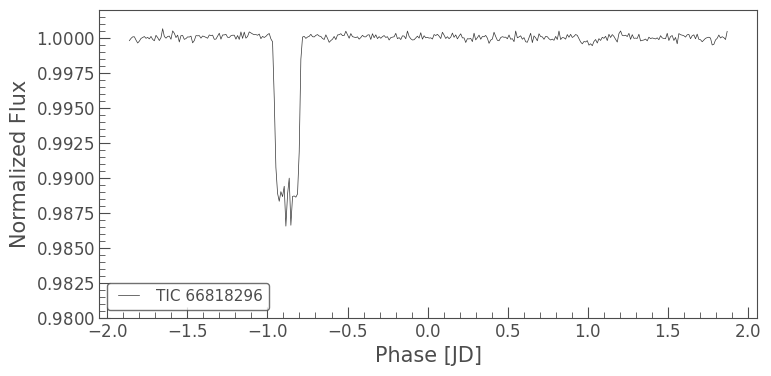

In [52]:
lc_folded = lc_clean.fold(period=pg.period_at_max_power, epoch_time=pg.transit_time[0]+2.3).bin(time_bin_size=0.0104)
ax = lc_folded.plot()
#ax.set_xlim(-0.3, 0.3)
ax.set_ylim(0.98, 1.002)